In [51]:
import glob
import warnings
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display as ipy_display

sys.path.insert(0, '../..')
import general_vars_cases_figname as mypy_cases

from shapely.geometry.base import BaseMultipartGeometry
if not hasattr(BaseMultipartGeometry, '__getitem__'):
    BaseMultipartGeometry.__getitem__ = lambda self, i: self.geoms[i]

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'font.size': 12})

In [52]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [53]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",
    cores=4,
    memory="32GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)
cluster.scale(jobs=16)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/42863/status,
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/42863/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.100:44707,Workers: 0
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/42863/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [54]:
# =====================================================================
# OPTIONS
# =====================================================================

# ── Variable to plot ──────────────────────────────────────────────────
#   'PRECT'   : daily total precipitation (GPCP + TRMM obs included)
#   'OMEGA500': 500 hPa vertical velocity diagnostic, daily (model only)
#   'PCONVT'  : convection-top pressure, daily (model only)
VAR = 'PCONVT'

VAR_CONFIG = {
    'PRECT': {
        'cam_vars'   : [('PRECC', 'PRECL'), 'PRECT'],  # try sum first, then PRECT
        'scale'      : 86400. * 1000.,                  # m/s -> mm day-1
        'units'      : 'mm day$^{-1}$',
        'lev'        : None,
        'hist_stream': 'h1a',
        'bins'       : np.logspace(np.log10(0.1), np.log10(300.), 51),
        'log_bins'   : True,
        'thresh'     : 0.1,                             # exclude drizzle below this
        'obs'        : True,
        'two_panels' : True,                            # freq + amount panels
        'invert_x'   : False,
    },
    'OMEGA500': {
        'cam_vars'   : ['OMEGA500'],                    # 2D diagnostic already at 500 hPa
        'scale'      : 864.,                            # Pa/s -> hPa day-1
        'units'      : 'hPa day$^{-1}$',
        'lev'        : None,
        'hist_stream': 'h1a',
        'bins'       : np.linspace(-200., 200., 81),
        'log_bins'   : False,
        'thresh'     : None,
        'obs'        : False,
        'two_panels' : False,
        'invert_x'   : False,
    },
    'PCONVT': {
        'cam_vars'   : ['PCONVT'],                      # convection-top pressure (Pa)
        'scale'      : 0.01,                            # Pa -> hPa
        'units'      : 'hPa',
        'lev'        : None,
        'hist_stream': 'h1a',
        'bins'       : np.linspace(50., 900., 86),      # 10 hPa bins; values > 900 hPa ignored
        'log_bins'   : False,
        'thresh'     : 1.,                              # exclude zero (no-convection grid points)
        'obs'        : False,
        'two_panels' : False,
        'invert_x'   : True,                            # low P (deep) on left, high P (shallow) right
    },
}

cfg = VAR_CONFIG[VAR]

# ── Paths ─────────────────────────────────────────────────────────────
ARCHIVE_DIR  = Path('/glade/derecho/scratch/rneale/archive')
DIR_FIG      = Path('/glade/u/home/rneale/python/python-figs/papers/ZM_PBL')
GPCP_PATH    = Path('/glade/campaign/cgd/amp/wchapman/Reanalysis/ERAi_Obs/gpcp_daily_precip_1997_2012.nc')
TRMM_PATH    = Path('/glade/campaign/cgd/amp/rneale/data/TRMM/daily/1deg/3B42.1998-2013.daily.1deg.v7.nc')
LANDFRAC_FILE = Path('/glade/derecho/scratch/rneale/archive/f.e30.FLTHIST.CAM7.L58.000a/atm/hist/'
                     'f.e30.FLTHIST.CAM7.L58.000a.cam.h0a.2004-12.nc')

# ── Cases ─────────────────────────────────────────────────────────────
lfcase = 5
dcases, _, _, fig_pref = mypy_cases.get_case_all(lfcase)
CASE_LABELS = list(dcases.keys())
CASES       = list(dcases.values())

# Per-case stream overrides: maps default stream name -> actual stream name.
# CAM6 uses h0/h1/h2; CAM7 cases use h0a/h1a/h2a.
CASE_HIST = {
    'CAM6': {'h1a': 'h1', 'h0a': 'h0'},
}

# ── Period / season / region ──────────────────────────────────────────
YEAR_START = 1990
YEAR_END   = 1999
SEASON     = 'JJA'          # 'DJF', 'MAM', 'JJA', 'SON', or None
LAT_BOUNDS = (-30., 30.)    # (lat_min, lat_max); None = global
LON_BOUNDS = (0.,  360.)    # (lon_min, lon_max); None = global

OBS_YEARS  = {'GPCP': (1997, 2012), 'TRMM': (2000, 2013)}

# ── Land / ocean masking ──────────────────────────────────────────────
#   None    : no masking (all surface types)
#   'land'  : land only  (LANDFRAC > LAND_THRESH)
#   'ocean' : ocean only (LANDFRAC < 1 - LAND_THRESH)
MASK        = None
LAND_THRESH = 0.5

BINS        = cfg['bins']
BIN_CENTRES = 0.5 * (BINS[:-1] + BINS[1:])
N_BINS      = len(BINS) - 1

print(f'Variable : {VAR}  |  stream: {cfg["hist_stream"]}')
print(f'Mask     : {MASK or "none"}')
print(f'Cases    : {CASE_LABELS}')
print(f'Period   : {YEAR_START}–{YEAR_END}  |  Season: {SEASON or "all"}')
print(f'Lat: {LAT_BOUNDS}  |  Lon: {LON_BOUNDS}')

Variable : PCONVT  |  stream: h1a
Mask     : none
Cases    : ['CAM7', 'CAM7-nozmpbl', 'CAM7-L32', 'CAM7-nozmpbl-L48', 'CAM7-nozmpbl-L32', 'CAM7-CAM6-phys', 'CAM6']
Period   : 1990–1999  |  Season: JJA
Lat: (-30.0, 30.0)  |  Lon: (0.0, 360.0)


In [55]:
# =====================================================================
# HELPER FUNCTIONS
# =====================================================================

# ── Colors matching set_params_lat in general_cesm_plot_utils ─────────
_PLOT_COLS = ['red', 'royalblue', 'darkorange', 'forestgreen', 'firebrick',
              'slateblue', 'goldenrod', 'pink', 'deepskyblue', 'crimson', 'purple', 'gray']
_OBS_LS    = ['-', '--', '-.', ':']
_OBS_NAMES = {'GPCP', 'TRMM'}

def case_style(name, obs_idx=0, model_idx=0):
    if name in _OBS_NAMES:
        return 'black', _OBS_LS[obs_idx % len(_OBS_LS)], 2.5, 10
    return _PLOT_COLS[model_idx % len(_PLOT_COLS)], '-', 1.8, 5


def get_cam_files(case, year_start, year_end, hist_stream='h1a'):
    hist_dir = ARCHIVE_DIR / case / 'atm' / 'hist'
    files = []
    for yr in range(year_start, year_end + 1):
        files.extend(sorted(hist_dir.glob(f'{case}.cam.{hist_stream}.{yr}-*.nc')))
    return sorted(files)


def apply_filters(da, lat_name='lat', lon_name='lon'):
    if SEASON:
        da = da.isel(time=(da.time.dt.season == SEASON).values)
    if LAT_BOUNDS:
        da = da.sel({lat_name: slice(min(LAT_BOUNDS), max(LAT_BOUNDS))})
    if LON_BOUNDS:
        da = da.sel({lon_name: slice(min(LON_BOUNDS), max(LON_BOUNDS))})
    return da


def apply_mask(da, lat_name='lat', lon_name='lon'):
    """Apply land/ocean mask to da, interpolating LANDFRAC to da's grid if needed."""
    if MASK is None:
        return da

    # Interpolate LANDFRAC onto da's lat/lon grid
    lf = _landfrac.interp(
        {lat_name: da[lat_name], lon_name: da[lon_name]},
        method='linear'
    )

    if MASK == 'land':
        da = da.where(lf > LAND_THRESH)
    elif MASK == 'ocean':
        da = da.where(lf < (1.0 - LAND_THRESH))
    return da


def compute_pdf(da, lat_name='lat'):
    """
    Area-weighted PDF. Works for log-spaced bins (PRECT) and linear bins (OMEGA).
    Returns (freq_pdf, amount_pdf) each of length N_BINS, normalised so that
    sum(pdf * bin_width) = 1  where bin_width is d(log r) or d(r) as appropriate.
    amount_pdf is only meaningful for positive-definite variables (PRECT).
    """
    lats    = da[lat_name].values
    weights = np.cos(np.deg2rad(lats))

    vals = da.values
    if vals.ndim == 2:
        vals = vals[np.newaxis]
    ntime, nlat, nlon = vals.shape
    w3d  = np.broadcast_to(weights[np.newaxis, :, np.newaxis], (ntime, nlat, nlon))

    thresh = cfg['thresh']
    if thresh is not None:
        mask = np.isfinite(vals) & (vals >= thresh)
    else:
        mask = np.isfinite(vals)

    flat_vals = vals[mask]
    flat_w    = w3d[mask]

    freq_pdf   = np.zeros(N_BINS)
    amount_pdf = np.zeros(N_BINS)
    for ib, (lo, hi) in enumerate(zip(BINS[:-1], BINS[1:])):
        sel = (flat_vals >= lo) & (flat_vals < hi)
        freq_pdf[ib]   = flat_w[sel].sum()
        amount_pdf[ib] = (flat_vals[sel] * flat_w[sel]).sum()

    # Normalise over appropriate bin measure
    if cfg['log_bins']:
        d_measure = np.diff(np.log(BINS))
    else:
        d_measure = np.diff(BINS)

    tot_f = (freq_pdf   * d_measure).sum()
    tot_a = (amount_pdf * d_measure).sum()
    if tot_f > 0: freq_pdf   /= tot_f
    if tot_a > 0: amount_pdf /= tot_a
    return freq_pdf, amount_pdf


# ── Load LANDFRAC mask (once, on model grid) ──────────────────────────
_ds_lf    = xr.open_dataset(LANDFRAC_FILE)
_landfrac = _ds_lf['LANDFRAC'].isel(time=0).drop_vars('time', errors='ignore').load()
_ds_lf.close()

if MASK:
    land_pct = float((_landfrac > LAND_THRESH).mean() * 100)
    print(f'LANDFRAC loaded: {_landfrac.sizes}  |  land coverage: {land_pct:.1f}%')
    print(f'Mask active: {MASK} (threshold={LAND_THRESH})')
else:
    print('LANDFRAC loaded (mask inactive — set MASK to "land" or "ocean" to use).')

print('Helper functions defined.')

LANDFRAC loaded (mask inactive — set MASK to "land" or "ocean" to use).
Helper functions defined.


In [56]:
# =====================================================================
# LOAD OBS  (PRECT only)
# =====================================================================

obs_pdfs = {}

if cfg['obs']:

    # ── GPCP ─────────────────────────────────────────────────────────
    print('Loading GPCP ...')
    ds  = xr.open_dataset(GPCP_PATH, chunks={'time': 200})
    ds  = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
    da  = ds['precip']   # already mm/day
    yr0, yr1 = OBS_YEARS['GPCP']
    da  = da.sel(time=slice(str(yr0), str(yr1)))
    da  = apply_filters(da)
    da  = apply_mask(da)
    da  = da.compute()
    obs_pdfs['GPCP'] = compute_pdf(da)
    print(f'  {da.sizes["time"]} days, mean = {float(da.mean()):.3g} mm/day')
    ds.close()

    # ── TRMM ─────────────────────────────────────────────────────────
    print('Loading TRMM ...')
    ds  = xr.open_dataset(TRMM_PATH, chunks={'time': 200})
    da  = ds['precip'].where(ds['precip'] >= 0)   # mask fill values; already mm/day
    yr0, yr1 = OBS_YEARS['TRMM']
    da  = da.sel(time=slice(str(yr0), str(yr1)))
    da  = apply_filters(da)
    da  = apply_mask(da)
    da  = da.compute()
    obs_pdfs['TRMM'] = compute_pdf(da)
    print(f'  {da.sizes["time"]} days, mean = {float(da.mean()):.3g} mm/day')
    ds.close()

else:
    print(f'No obs configured for {VAR} — skipping obs cell.')

print('Done.')

No obs configured for PCONVT — skipping obs cell.
Done.


In [57]:
# =====================================================================
# LOAD MODEL DATA AND COMPUTE PDFS
# =====================================================================

model_pdfs = {}

for label, case in zip(CASE_LABELS, CASES):
    # Resolve stream: use per-case override if defined, else variable default
    default_stream = cfg['hist_stream']
    hist_stream    = CASE_HIST.get(label, {}).get(default_stream, default_stream)

    files = get_cam_files(case, YEAR_START, YEAR_END, hist_stream)
    if not files:
        print(f'  {label}: no files ({hist_stream}) — skipping')
        model_pdfs[label] = None
        continue
    print(f'  {label}: {len(files)} files [{hist_stream}]', end='  ', flush=True)

    ds = xr.open_mfdataset(
        files,
        combine='by_coords',
        data_vars='minimal', coords='minimal',
        compat='override', join='override',
        parallel=True, chunks={'time': 50},
    )

    # ── Extract variable ──────────────────────────────────────────────
    da = None
    for vspec in cfg['cam_vars']:
        if isinstance(vspec, tuple):           # e.g. ('PRECC', 'PRECL')
            if all(v in ds for v in vspec):
                da = sum(ds[v] for v in vspec) * cfg['scale']
                break
        elif vspec in ds:
            da = ds[vspec] * cfg['scale']
            break

    if da is None:
        print(f'variable not found in {hist_stream} — skipping')
        model_pdfs[label] = None
        ds.close()
        continue

    # ── Level selection for 3D variables ─────────────────────────────
    if cfg['lev'] is not None and 'lev' in da.dims:
        lev_vals   = da.lev.values
        target_lev = cfg['lev'] * 100. if lev_vals.max() > 2000 else cfg['lev']
        da = da.sel(lev=target_lev, method='nearest')
        actual_lev = float(da.lev) if 'lev' in da.coords else target_lev
        print(f'lev={actual_lev:.1f}', end='  ')

    da = apply_filters(da)
    da = apply_mask(da)      # land/ocean mask (no-op if MASK is None)
    da = da.compute()
    ds.close()

    model_pdfs[label] = compute_pdf(da)
    print(f'mean={float(da.mean()):.3g} {cfg["units"]}  n={da.sizes["time"]}')

print('\nModels done.')

  CAM7: 365 files [h1a]  mean=890 hPa  n=920
  CAM7-nozmpbl: 365 files [h1a]  mean=831 hPa  n=920
  CAM7-L32: 365 files [h1a]  mean=880 hPa  n=920
  CAM7-nozmpbl-L48: 365 files [h1a]  mean=853 hPa  n=920
  CAM7-nozmpbl-L32: 365 files [h1a]  mean=834 hPa  n=920
  CAM7-CAM6-phys: 365 files [h1a]  mean=830 hPa  n=920
  CAM6: 365 files [h1]  mean=825 hPa  n=920

Models done.


Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/zmpbl_paper1_PCONVT_pdf_JJA_-30.0to30.0_1990-1999.png


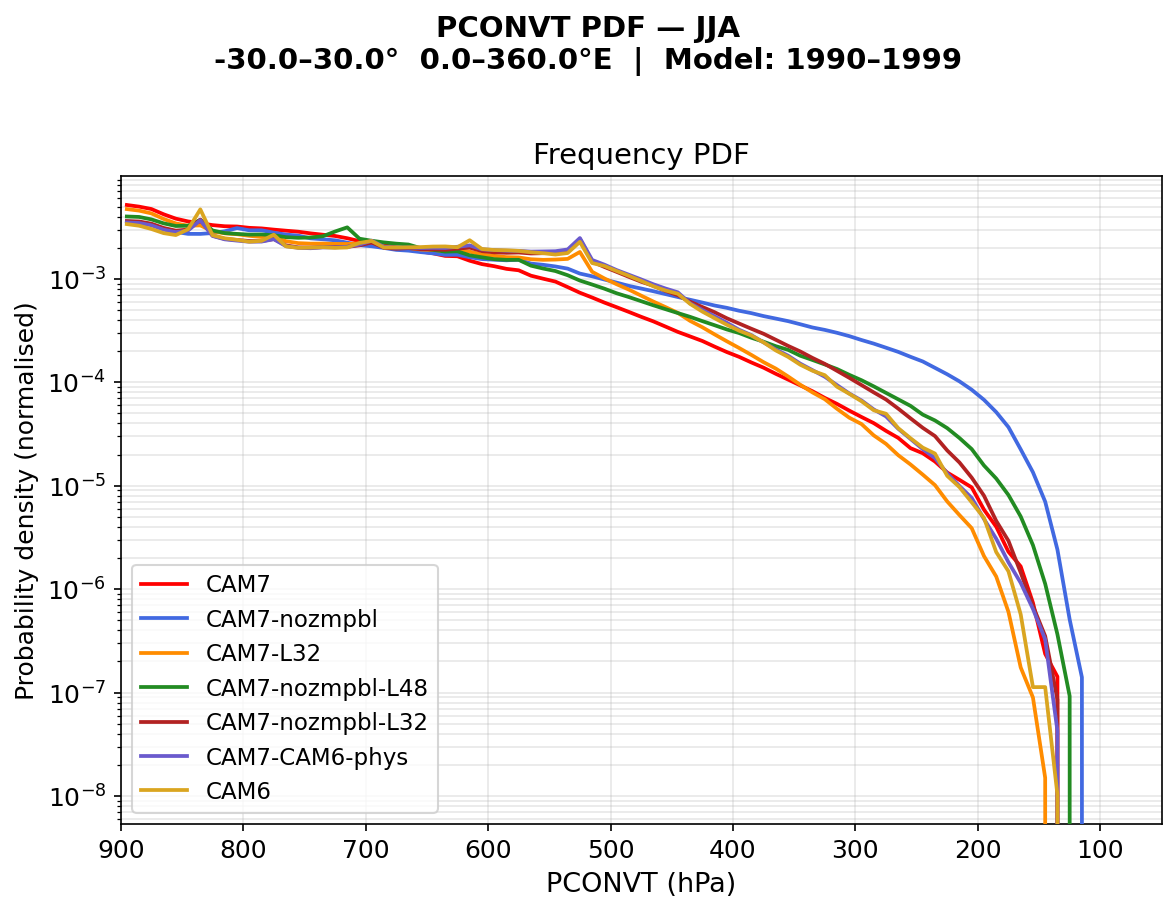

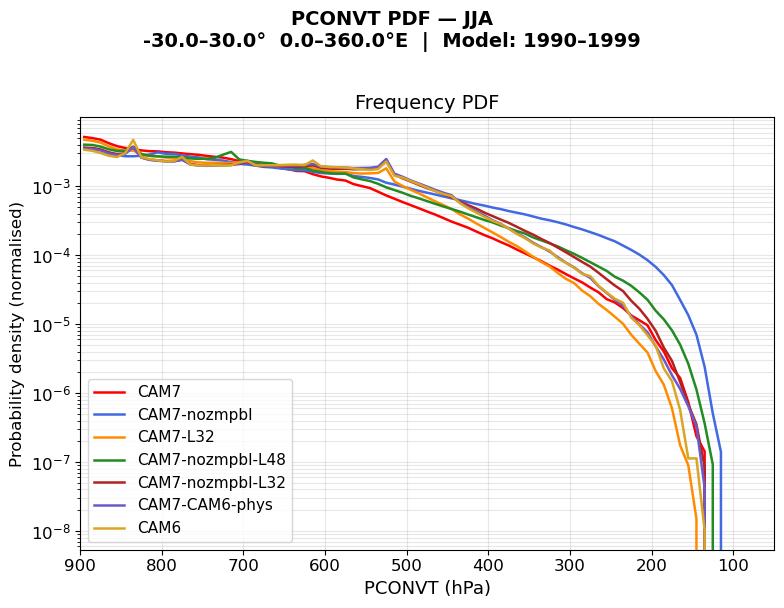

In [58]:
# =====================================================================
# PLOT PDFs
# =====================================================================

two_panels = cfg['two_panels']
fig, axes  = plt.subplots(1, 2 if two_panels else 1, figsize=(15 if two_panels else 8, 6))
if not two_panels:
    axes = [axes]

ax_freq = axes[0]
ax_freq.set_title('Frequency PDF', fontsize=14)
if two_panels:
    axes[1].set_title('Amount PDF  (rate × frequency)', fontsize=14)

# ── Plot obs ──────────────────────────────────────────────────────────
obs_idx = 0
for obs_name, pdfs in obs_pdfs.items():
    col, ls, lw, zo = case_style(obs_name, obs_idx=obs_idx)
    freq_pdf, amount_pdf = pdfs
    ax_freq.plot(BIN_CENTRES, freq_pdf, color=col, ls=ls, lw=lw, zorder=zo, label=obs_name)
    if two_panels:
        axes[1].plot(BIN_CENTRES, amount_pdf, color=col, ls=ls, lw=lw, zorder=zo, label=obs_name)
    obs_idx += 1

# ── Plot model cases ──────────────────────────────────────────────────
model_idx = 0
for label in CASE_LABELS:
    pdfs = model_pdfs.get(label)
    if pdfs is None:
        model_idx += 1
        continue
    col, ls, lw, zo = case_style(label, model_idx=model_idx)
    freq_pdf, amount_pdf = pdfs
    ax_freq.plot(BIN_CENTRES, freq_pdf, color=col, ls=ls, lw=lw, zorder=zo, label=label)
    if two_panels:
        axes[1].plot(BIN_CENTRES, amount_pdf, color=col, ls=ls, lw=lw, zorder=zo, label=label)
    model_idx += 1

# ── Axis formatting ───────────────────────────────────────────────────
season_str = SEASON or 'All seasons'
lat_str    = f'{min(LAT_BOUNDS)}–{max(LAT_BOUNDS)}°' if LAT_BOUNDS else 'Global'
lon_str    = f'{min(LON_BOUNDS)}–{max(LON_BOUNDS)}°E' if LON_BOUNDS else ''
lev_str    = f' @ {cfg["lev"]} hPa' if cfg['lev'] else ''
mask_str   = f'  |  {MASK} only' if MASK else ''

for ax in axes:
    if cfg['log_bins']:
        ax.set_xscale('log')
        ax.set_xlim(BINS[0], BINS[-1])
    else:
        ax.set_xlim(BINS[0], BINS[-1])
        if not cfg['invert_x']:
            ax.axvline(0, color='gray', lw=0.8, ls='--')
    if cfg['invert_x']:
        ax.invert_xaxis()
    ax.set_yscale('log')
    ax.set_xlabel(f'{VAR}{lev_str} ({cfg["units"]})', fontsize=13)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=11, framealpha=0.8)

axes[0].set_ylabel('Probability density (normalised)', fontsize=12)
if two_panels:
    axes[1].set_ylabel('Amount density (normalised)', fontsize=12)

fig.suptitle(
    f'{VAR}{lev_str} PDF — {season_str}{mask_str}\n{lat_str}  {lon_str}  |  Model: {YEAR_START}–{YEAR_END}',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

season_tag = SEASON or 'ALL'
lat_tag    = f'{min(LAT_BOUNDS)}to{max(LAT_BOUNDS)}' if LAT_BOUNDS else 'global'
lev_tag    = f'_{int(cfg["lev"])}hPa' if cfg['lev'] else ''
mask_tag   = f'_{MASK}' if MASK else ''
fpath = DIR_FIG / f'{fig_pref}_{VAR}{lev_tag}_pdf_{season_tag}_{lat_tag}{mask_tag}_{YEAR_START}-{YEAR_END}.png'
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print('Saved:', fpath)
ipy_display(Image(str(fpath)))